**Step 1: Install Kaggle API**

In [1]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.5/128.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.2/229.2 kB 19.3 MB/s eta 0:00:00


S**tep 2: Load Kaggle Credentials from Colab Secrets**
Before running this cell, add these two secrets in Colab:

KAGGLE_USERNAME
KAGGLE_KEY
Go to the left sidebar in Colab → click the key icon → add both secrets.

In [2]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

print("Kaggle credentials loaded successfully.")

Kaggle credentials loaded successfully.


**Step 3: Download Dataset from Kaggle**
We will use the Microsoft Cats vs Dogs dataset.

In [3]:
!mkdir -p /content/data
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset -p /content/data


Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:11<00:00, 72.0MB/s]



Step 4: Unzip **Dataset**

In [4]:
import zipfile
import os

zip_path = "/content/data/microsoft-catsvsdogs-dataset.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


**Step 5: Check Dataset Structure**

In [5]:
base_dir = "/content/data/PetImages"

print("Available folders:", os.listdir(base_dir))
print("Cat images:", len(os.listdir(os.path.join(base_dir, "Cat"))))
print("Dog images:", len(os.listdir(os.path.join(base_dir, "Dog"))))



Available folders: ['Dog', 'Cat']
Cat images: 12501
Dog images: 12501


**Step 6: Remove Corrupted Images**
This Kaggle dataset contains a few corrupted images.
If we do not remove them, training may stop with an error.

In [6]:
from PIL import Image

classes = ["Cat", "Dog"]
removed = 0

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except Exception:
            os.remove(img_path)
            print(class_name)
            removed += 1

print("Corrupted images removed:", removed)


Cat
Cat
Dog


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Dog
Corrupted images removed: 4


**Step 7: Create Training and Validation Data with Augmentation**
Why Data Augmentation Helps
Data augmentation creates modified versions of training images:

rotated images
shifted images
zoomed images
flipped images
This helps the model learn general cat/dog features instead of memorizing images.

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    # Overfitting reduction through augmentation
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("Class labels:", train_data.class_indices)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class labels: {'Cat': 0, 'Dog': 1}


**Step 8: Visualize Augmented Images**
This helps us understand how the model sees transformed training images.

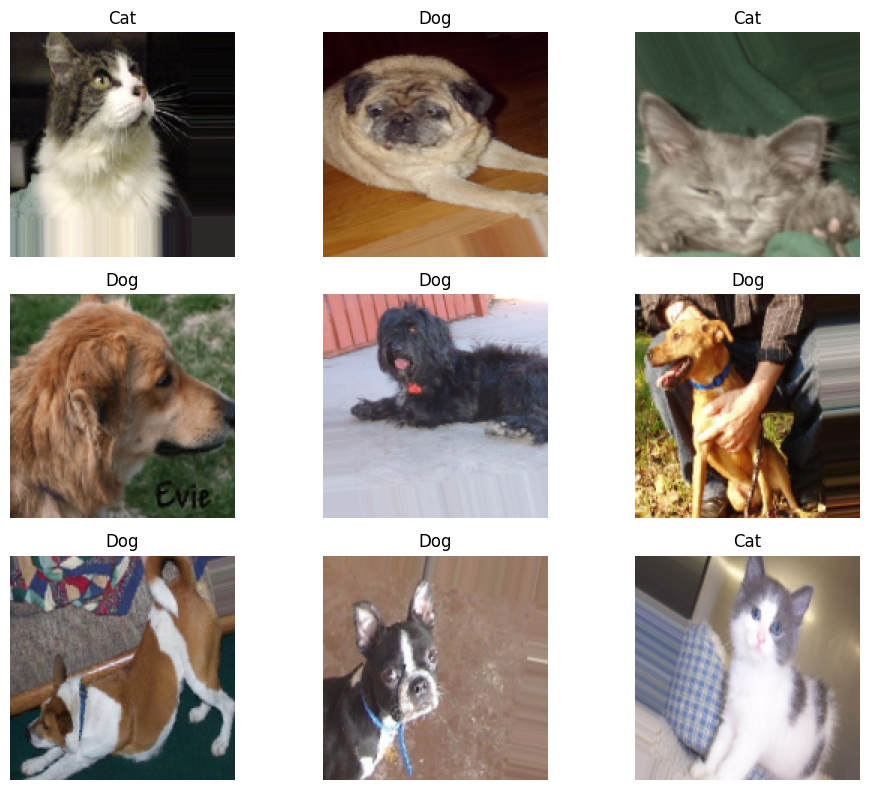

In [8]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Step 9: Build Improved Basic CNN Model**
This is still a basic CNN, but it is designed to reduce overfitting.

Important changes:

BatchNormalization() after convolution layers
Dropout() after pooling layers
L2 regularization in Conv2D and Dense layers
GlobalAveragePooling2D() instead of Flatten()
Flatten() can create many parameters and increase overfitting.
GlobalAveragePooling2D() reduces parameters and improves generalization.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

model = Sequential([
  #block 1
    Conv2D(
        32, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001),
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),
  #block 2
    Conv2D(
        64, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.30),
  #block 3
    Conv2D(
        128, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.35),
  #block 4
 Conv2D(
        256, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.40),
#block 5
Conv2D(
     512, (3,3), activation="relu", padding="same",
     kernel_regularizer=l2(0.001)
  ),
  BatchNormalization(),
  MaxPooling2D(2,2),
  Dropout(0.45),

#transition to dense
    GlobalAveragePooling2D(),
#dense layers
    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.50),
    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.40),

#output layer
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 9, 9, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 9, 9, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        65,66

 Total params: 1,646,529 (6.28 MB)

 Trainable params: 1,644,545 (6.27 MB)

 Non-trainable params: 1,984 (7.75 KB)

**Step 10: Compile Model**
We use a smaller learning rate to make training more stable.

In [14]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

**Step 11: Train Model with Callbacks**
CallbackExplanation                                                                        
**EarlyStopping   **                                                                         
Stops training if validation loss does not improve.

**ReduceLROnPlateau**
Reduces learning rate when validation loss stops improving.

**ModelCheckpoint**
Saves the best model based on validation accuracy.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7
    ),

    ModelCheckpoint(
        "/content/best_cat_dog_basic_cnn_overfitting_solution.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
150/625 ━━━━━━━━━━━━━━━━━━━━ 1:46 225ms/step - accuracy: 0.5073 - loss: 1.8403

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.5375 - loss: 1.7078

625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 248ms/step - accuracy: 0.5591 - loss: 1.6252 - val_accuracy: 0.5406 - val_loss: 1.8101 - learning_rate: 1.0000e-04
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.5857 - loss: 1.5361

625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.5910 - loss: 1.5176 - val_accuracy: 0.6028 - val_loss: 1.6212 - learning_rate: 1.0000e-04
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 242ms/step - accuracy: 0.6190 - loss: 1.4412 - val_accuracy: 0.5952 - val_loss: 1.5940 - learning_rate: 1.0000e-04
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6404 - loss: 1.3768

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 236ms/step - accuracy: 0.8543 - loss: 0.5844 - val_accuracy: 0.8737 - val_loss: 0.5440 - learning_rate: 1.0000e-04
Epoch 19/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8608 - loss: 0.5645

625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 236ms/step - accuracy: 0.8605 - loss: 0.5683 - val_accuracy: 0.8876 - val_loss: 0.5150 - learning_rate: 1.0000e-04
Epoch 20/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 238ms/step - accuracy: 0.8662 - loss: 0.5452 - val_accuracy: 0.8617 - val_loss: 0.5516 - learning_rate: 1.0000e-04
Epoch 21/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.8734 - loss: 0.5304 - val_accuracy: 0.8776 - val_loss: 0.5530 - learning_rate: 1.0000e-04
Epoch 22/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.8687 - loss: 0.5317

625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.8729 - loss: 0.5216 - val_accuracy: 0.8996 - val_loss: 0.4571 - learning_rate: 1.0000e-04
Epoch 23/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 239ms/step - accuracy: 0.8806 - loss: 0.5020 - val_accuracy: 0.8996 - val_loss: 0.4652 - learning_rate: 1.0000e-04
Epoch 24/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.8791 - loss: 0.4967 - val_accuracy: 0.8866 - val_loss: 0.4711 - learning_rate: 1.0000e-04
Epoch 25/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8879 - loss: 0.4815

625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 236ms/step - accuracy: 0.8859 - loss: 0.4811 - val_accuracy: 0.9234 - val_loss: 0.4001 - learning_rate: 1.0000e-04
Epoch 26/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 234ms/step - accuracy: 0.8907 - loss: 0.4661 - val_accuracy: 0.9104 - val_loss: 0.4252 - learning_rate: 1.0000e-04
Epoch 27/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 234ms/step - accuracy: 0.8953 - loss: 0.4564 - val_accuracy: 0.8970 - val_loss: 0.4577 - learning_rate: 1.0000e-04
Epoch 28/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.8972 - loss: 0.4466 - val_accuracy: 0.9186 - val_loss: 0.4020 - learning_rate: 1.0000e-04
Epoch 29/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9048 - loss: 0.4294

625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 262ms/step - accuracy: 0.9075 - loss: 0.4258 - val_accuracy: 0.9302 - val_loss: 0.3699 - learning_rate: 3.0000e-05
Epoch 30/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.9061 - loss: 0.4209 - val_accuracy: 0.9238 - val_loss: 0.3786 - learning_rate: 3.0000e-05


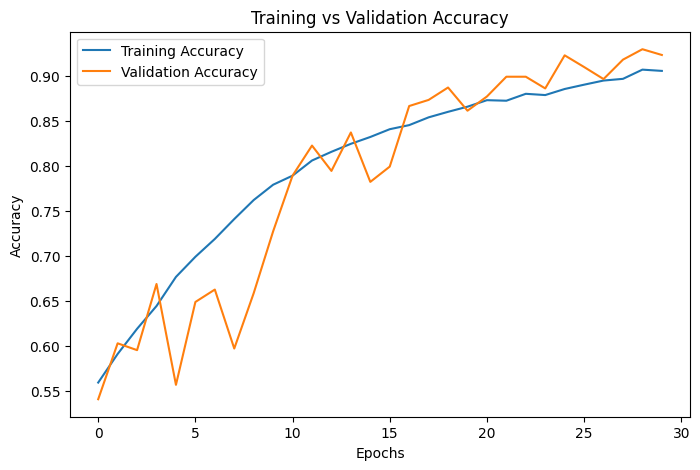

In [16]:
"""Step 12: Plot Accuracy Graph
How to Read This Graph
If training accuracy keeps increasing but validation accuracy stays low, the model is overfitting.

A better model has training and validation accuracy close to each other."""
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

**Step 13: Plot Loss Graph**
How to Read This Graph
If training loss decreases but validation loss increases, the model is overfitting.

A better model has both losses decreasing or staying close.

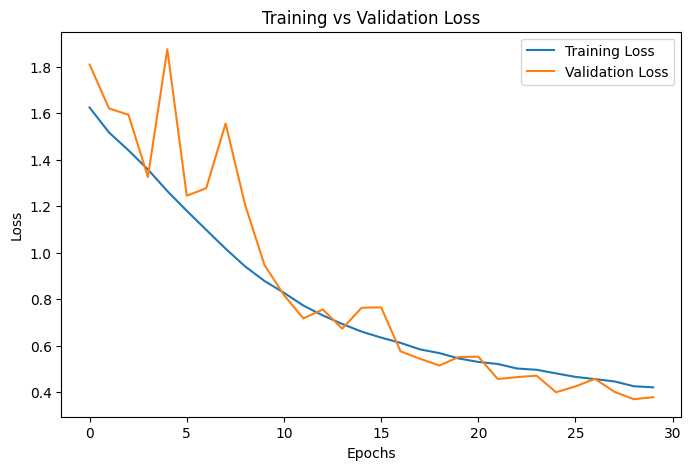

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

**Step 14: Evaluate Best Model**

In [18]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)


157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9302 - loss: 0.3699
Validation Loss: 0.36992889642715454
Validation Accuracy: 0.9301720857620239


**step 15: Load Best Saved Model**
Use this cell if you want to load the best saved model later.

In [19]:
from tensorflow.keras.models import load_model

best_model = load_model("/content/best_cat_dog_basic_cnn_overfitting_solution.h5")

print("Best model loaded successfully.")

Best model loaded successfully.


**Step 16: Upload One Image and Predict**
This cell lets the user upload any cat/dog image and get prediction.

Saving WhatsApp Image 2026-05-21 at 21.57.54.jpeg to WhatsApp Image 2026-05-21 at 21.57.54.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


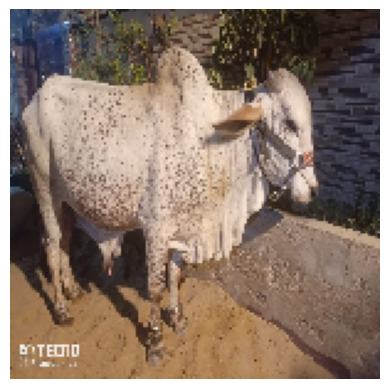

Prediction: Unknown / Other Animal


In [23]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

uploaded = files.upload()

for file_name in uploaded.keys():
    img_path = file_name

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = best_model.predict(img_array)

    plt.imshow(img)
    plt.axis("off")
    plt.show()
score = float(prediction[0][0])

if score > 0.8:
    print("Prediction: Dog")
elif score < 0.2:
    print("Prediction: Cat")
else:
    print("Prediction: Unknown / Other Animal")
